In [3]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher

ds = load_dataset('512duncanl/wi_locness_detokenized', split='train')
df = pd.DataFrame({'original_text': ds['input'], 'corrected_text': ds['output']})

print(f'Total examples: {len(df)}')
df.head()

/home/baz/anaconda3/envs/stat303_conda_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total examples: 38692


,original_text,corrected_text
0,My town is a medium size city with eighty thou...,My town is a medium - sized city with eighty t...
1,It has a high density population because its s...,It has a high density population because of it...
2,"Despite of it is an industrial city, there are...","Although it is an industrial city, there are m..."
3,I recommend visiting the artificial lake in th...,I recommend visiting the artificial lake in th...
4,Pasteries are very common and most of them off...,Pasteries are very common and most of them off...


Sentence length stats:
       original_len  corrected_len      len_diff
count  38692.000000   38692.000000  38692.000000
mean      16.514086      16.616251      0.102166
std       11.215221      11.303113      0.962575
min        1.000000       0.000000    -21.000000
25%        9.000000       9.000000      0.000000
50%       15.000000      15.000000      0.000000
75%       21.000000      21.000000      0.000000
max      205.000000     210.000000     18.000000


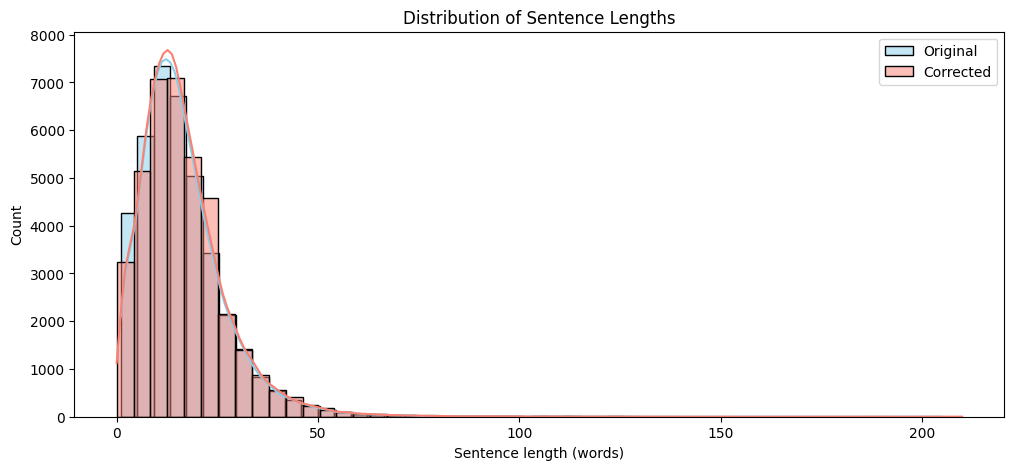

In [4]:
df['original_len'] = df['original_text'].apply(lambda x: len(str(x).split()))
df['corrected_len'] = df['corrected_text'].apply(lambda x: len(str(x).split()))
df['len_diff'] = df['corrected_len'] - df['original_len']

print("Sentence length stats:")
print(df[['original_len','corrected_len','len_diff']].describe())

plt.figure(figsize=(12,5))
sns.histplot(df['original_len'], color='skyblue', label='Original', kde=True, bins=50)
sns.histplot(df['corrected_len'], color='salmon', label='Corrected', kde=True, bins=50)
plt.xlabel("Sentence length (words)")
plt.ylabel("Count")
plt.title("Distribution of Sentence Lengths")
plt.legend()
plt.show()


Diff ratio stats:
count    38692.000000
mean         0.052516
std          0.098474
min          0.000000
25%          0.000000
50%          0.022472
75%          0.066667
max          1.000000
Name: diff_ratio, dtype: float64


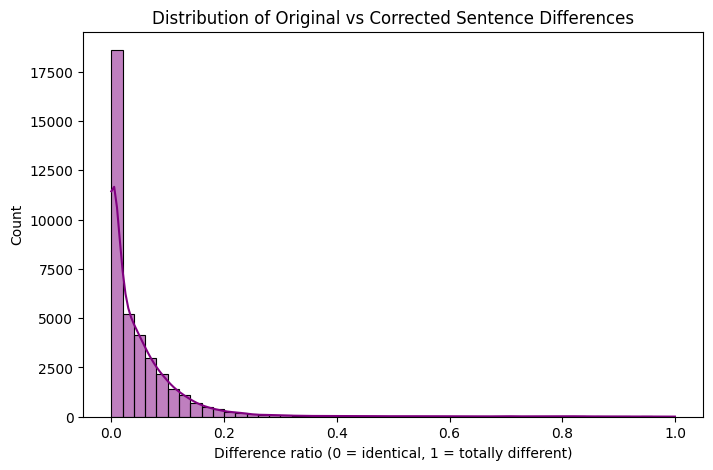

In [5]:

def diff_ratio(a, b):
    return 1 - SequenceMatcher(None, a, b).ratio()

df['diff_ratio'] = df.apply(lambda x: diff_ratio(str(x['original_text']), str(x['corrected_text'])), axis=1)

print("Diff ratio stats:")
print(df['diff_ratio'].describe())

plt.figure(figsize=(8,5))
sns.histplot(df['diff_ratio'], bins=50, kde=True, color='purple')
plt.xlabel("Difference ratio (0 = identical, 1 = totally different)")
plt.ylabel("Count")
plt.title("Distribution of Original vs Corrected Sentence Differences")
plt.show()


In [6]:
print("Random examples with changes:")
for i, row in df.sample(5, random_state=42).iterrows():
    print(f"\nOriginal:  {row['original_text']}")
    print(f"Corrected: {row['corrected_text']}")
    print(f"Words diff: {row['len_diff']}, Diff ratio: {row['diff_ratio']:.2f}")


Random examples with changes:

Original:  Recently, governments in many countries, put a ban for parking or even a ban for driving in major city centres, because this leads to increasing traffic jams.
Corrected: Recently, governments in many countries imposed a ban on parking or even a ban on driving in major city centres, because this leads to increasing traffic jams.
Words diff: 0, Diff ratio: 0.05

Original:  They grabbed the body and soaked him on fuel.
Corrected: They grabbed the body and soaked it in fuel.
Words diff: 0, Diff ratio: 0.06

Original:  Especially with their mothers, girlfriends or wives.
Corrected: Especially with their mothers, girlfriends or wives.
Words diff: 0, Diff ratio: 0.00

Original:  The people I interviewed are very keen on reality shows like "Big Brother" and similar but I have to say that many of them are also interested in cooking shows and documentaries.
Corrected: The people I interviewed are very keen on reality shows like "Big Brother" and similar,

In [7]:
high_diff = df[df['diff_ratio'] > 0.3]
print(f"\nSentences with diff_ratio > 0.3: {len(high_diff)}")
high_diff.sample(5, random_state=42)



Sentences with diff_ratio > 0.3: 874


,original_text,corrected_text,original_len,corrected_len,len_diff,diff_ratio
34473,to summaries it is different from some oneis o...,"To summarise, it is different from some oneis ...",41,41,0,0.366071
7651,"Michael went into the teacher office, but he f...","Michael went into the teacher's office, but he...",78,81,3,0.461802
9470,I am here to write about a composition about p...,I am here to write a composition about public ...,57,55,-2,0.706395
27783,Considering how much time children spend at sc...,Considering how much time children spend at sc...,111,113,2,0.871816
10533,I would like to tell you that I have done a co...,I would like to tell you that I have done a co...,67,65,-2,0.800878
